## Modeling for predicting hospitalization at ED triage

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
# import sys, numpy
# print("Python:", sys.version)
# print("NumPy:", numpy.__version__)
# !pip install "tensorflow<2.18" "numpy<2"

In [2]:
#!pip install "tensorflow==2.15.*" "tf-keras==2.15.*"
#import tf_keras as keras  # <— legacy TF-Keras

In [3]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve
import tf_keras as keras
from dataset_path import output_path

df_train = pd.read_csv('mv_train.csv')
df_test = pd.read_csv('mv_test.csv')
df_val = pd.read_csv("mv_val.csv")
confidence_interval = 95
random_seed=0

2026-03-23 15:05:21.213629: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 15:05:21.514699: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-23 15:05:22.350344: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-23 15:05:22.350439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-23 15:05:22.500227: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [4]:
random.seed(random_seed)
np.random.seed(random_seed)

In [5]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 
df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,69219,12174269,NaN,32252456,2115-03-05 18:52:00,2115-03-05 18:54:00,30,F,2115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2115,30,False,False,False,0 days 00:02:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,0.03,NaN,NaN,36.722222,70.0,20.0,100.0,142.0,71.0,5.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.833333,73.0,16.0,98.0,117.0,79.0,5.0,0.0,1.0,94.666667,0,0,0,0,0,1,train,examination ankle ap mortise and lat left indi...,['files/p1217/p12174269/s47575777/47575777']
1,374706,16975219,NaN,36792323,2123-11-26 04:52:00,2123-11-26 06:13:00,47,M,2121,NaN,NaN,NaN,NaN,HISPANIC/LATINO,NaN,NaN,NaN,2123,49,False,False,False,0 days 01:21:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,1.35,NaN,NaN,37.388889,112.0,18.0,95.0,140.0,97.0,10.000000,...,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,36.611111,85.0,18.0,97.0,113.0,73.0,7.0,5.0,0.0,111.333333,1,4,6,3,2,3,train,indication year old man with right shoulder pa...,['files/p1697/p16975219/s49058539/49058539']
2,392693,10199379,NaN,38089639,2161-04-10 13:43:00,2161-04-10 13:49:00,30,F,2157,NaN,NaN,NaN,NaN,WHITE,NaN,NaN,NaN,2161,34,False,False,False,0 days 00:06:00,NaN,NaN,False,False,False,0,0,2,NaN,NaN,False,0,0,2,0,0,0,0.10,NaN,NaN,36.222222,80.0,20.0,100.0,133.0,93.0,0.000000,...,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,37.055556,77.0,16.0,100.0,107.0,75.0,0.0,0.0,2.0,106.333333,1,0,0,0,0,1,test,i ve been getting more i scheduled an appointm...,['files/p1019/p10199379/s41948308/41948308']
3,386691,19101434,25207489.0,33105183,2191-05-10 20:19:00,2191-05-10 22:27:54,64,M,2188,NaN,2191-05-10 22:26:00,2191-05-11 14:53:00,NaN,WHITE,2191-05-10 20:19:00,2191-05-11 00:24:00,Other,2191,67,False,False,False,0 days 02:08:54,NaN,NaN,False,True,False,1,3,3,2191-10-13 11:10:00,155 days 12:42:06,False,1,2,2,0,0,0,2.15,NaN,155.53,36.712811,86.0,16.0,94.0,151.0,88.0,4.167576,...,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,36.666667,78.0,18.0,97.0,157.0,92.0,4.0,5.0,6.0,109.000000,3,4,5,1,0,1,train,malaise hypotension baradycardia anemia mr is ...,['files/p1910/p19101434/s44754723/44754723']
4,20499,13593727,25433469.0,34482189,2113-05-24 15:20:00,2113-05-24 20:50:19,52,M,2112,NaN,2113-05-24 20:49:00,2113-05-30 20:01:00,NaN,BLACK/AFRICAN AMERICAN,2113-05-24 15:20:00,2113-05-25 04:34:00,Other,2113,53,False,False,False,0 days 05:30:19,NaN,NaN,False,True,False,0,0,0,2113-05-31 13:34:00,6 days 16:43:41,False,0,0,2,0,0,0,5.51,NaN,6.70,36.833333,79.0,18.0,99.0,115.0,62.0,7.000000,...,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.722222,78.0,18.0,98.0,128.0,68.0,8.0,5.0,13.0,79.666667,4,0,2,0,0,1,train,esrd mr is a year old male with hep c w fibros...,['files/p13

### 1. Task-specific filter: No task-specific exclusion needed

In [6]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 130094 , testing size = 16262


### 2. Variable Selection

In [7]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_temperature", "triage_heartrate", "triage_resprate", 
            "triage_o2sat", "triage_sbp", "triage_dbp", "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache",
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope", 
            "chiefcom_dizziness", 
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", 
            "cci_Pulmonary", "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", 
            "cci_DM2", "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", 
            "cci_Cancer2", "cci_HIV", 
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2", 
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss",
            "eci_Anemia", "eci_Alcohol", "eci_Drugs","eci_Psychoses", "eci_Depression"]

outcome = "outcome_hospitalization"

In [8]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [9]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64


In [10]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [11]:
print('class ratio')
ratio = y_train.sum()/(~y_train).sum()
print('positive : negative =', ratio, ': 1')

class ratio
positive : negative = 1.478500257196746 : 1


### 3.  Modeling script

In [12]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 5.117947816848755 seconds
AUC: 0.7780993130052677
AUPRC: 0.8209509131830697
Sensitivity: 0.7182588916459884
Specificity: 0.7080424886191199
Score thresold: 0.57413640980797
2.5 97.5


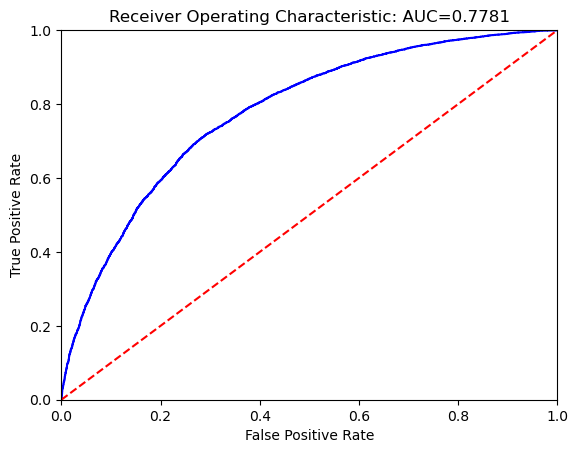

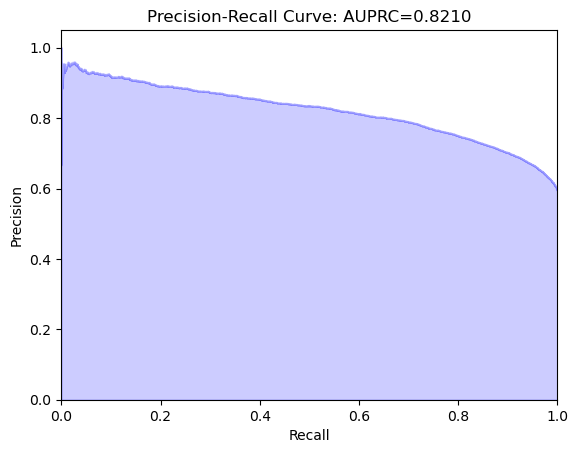

In [13]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task1_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 17.787192821502686 seconds
AUC: 0.7872574306761002
AUPRC: 0.8296670433373649
Sensitivity: 0.7199131513647643
Specificity: 0.7050075872534143
Score thresold: 0.5950000000000001
2.5 97.5


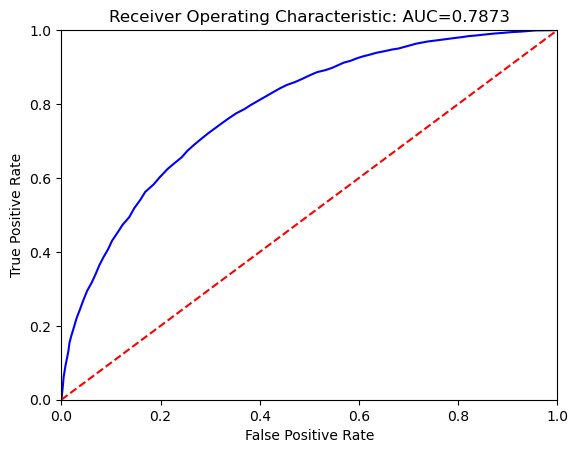

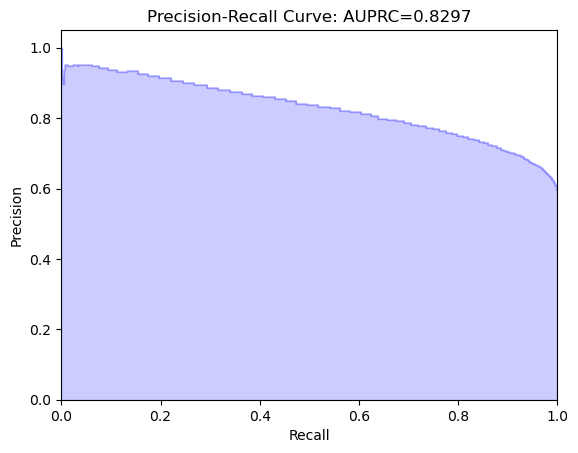

[0.08711945 0.01325598 0.00895056 0.01465715 0.02812746 0.00766606
 0.01823673 0.03574489 0.00153739 0.00350897 0.00920442 0.06843343
 0.07423656 0.03629727 0.04063859 0.07492217 0.07100773 0.04426393
 0.08609146 0.00829828 0.0084412  0.00580091 0.00064889 0.00445888
 0.0032886  0.00383364 0.00506072 0.0030042  0.00477516 0.00648062
 0.01031505 0.00620263 0.00593816 0.00286442 0.01005837 0.00409708
 0.00289813 0.00639044 0.0096954  0.00634254 0.00240383 0.00842434
 0.00727162 0.00258352 0.00354713 0.00165166 0.01170779 0.00572615
 0.00508548 0.00823821 0.01144815 0.00738868 0.00762375 0.00196267
 0.0069818  0.00813282 0.00576696 0.01656032 0.00216451 0.00598669
 0.00675606 0.00555316 0.00393199 0.0103092 ]


In [14]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 22.283066749572754 seconds
AUC: 0.7922129065518977
AUPRC: 0.8394856881823984
Sensitivity: 0.722808105872622
Specificity: 0.7110773899848255
Score thresold: 0.597662659360254
2.5 97.5


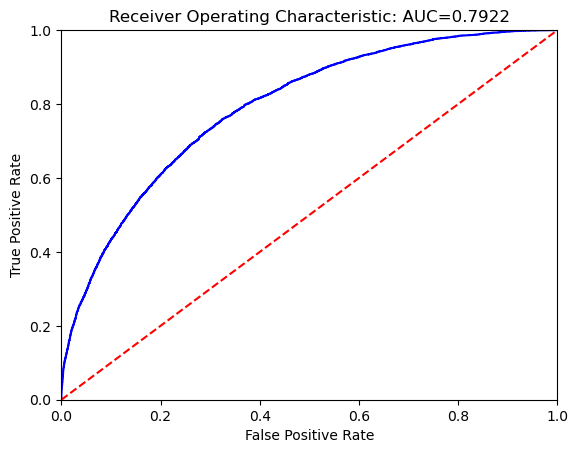

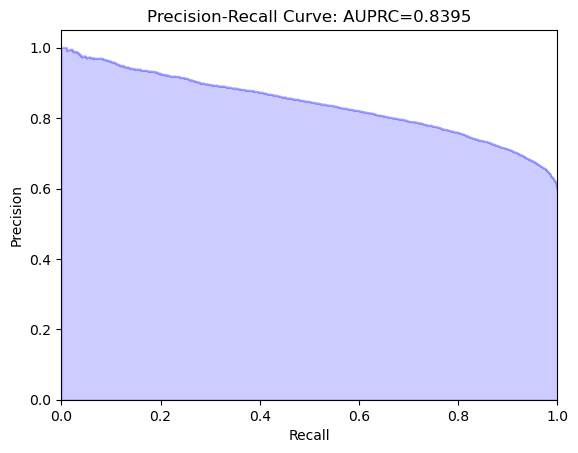

In [15]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [16]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.428050
1,1,1,0.495168
2,2,0,0.079507
3,3,1,0.552566
4,4,1,0.720961


GradientBoosting:
Training time: 22.28999900817871 seconds
AUC: 0.7918924699826078
AUPRC: 0.8364049936571971
Sensitivity: 0.7260387524608849
Specificity: 0.7088186356073212
Score thresold: 0.5928765126932007
2.5 97.5


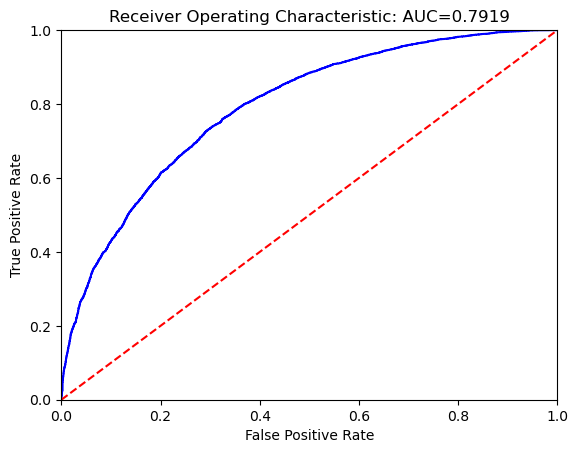

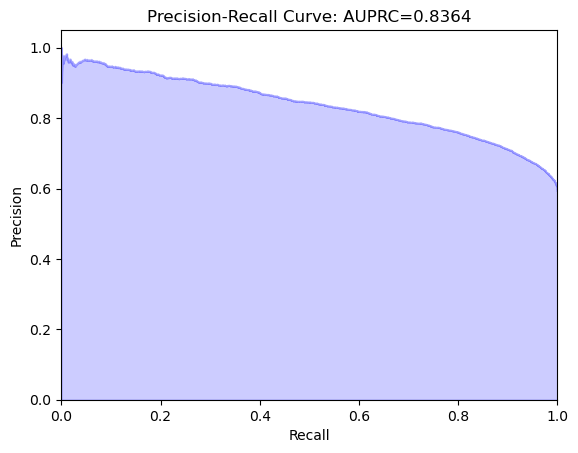

In [17]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [18]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.893304
1,1,1,0.713969
2,2,0,0.716149
3,3,1,0.918504
4,4,1,0.541204


In [19]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)


2026-03-23 15:07:01.814454: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agd07
2026-03-23 15:07:01.814478: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agd07
2026-03-23 15:07:01.814552: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-03-23 15:07:01.814580: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


Epoch 1/20
651/651 [==============================] - 1s 1ms/step - loss: 0.6158 - accuracy: 0.6821 - auc: 0.7237 - auprc: 0.7731 - tp: 60169.0000 - tn: 28566.0000 - precision: 0.7155 - recall: 0.7753
Epoch 2/20
651/651 [==============================] - 1s 980us/step - loss: 0.5682 - accuracy: 0.7078 - auc: 0.7614 - auprc: 0.8116 - tp: 61777.0000 - tn: 30301.0000 - precision: 0.7357 - recall: 0.7960
Epoch 3/20
651/651 [==============================] - 1s 1ms/step - loss: 0.5618 - accuracy: 0.7124 - auc: 0.7679 - auprc: 0.8173 - tp: 62062.0000 - tn: 30612.0000 - precision: 0.7394 - recall: 0.7997
Epoch 4/20
651/651 [==============================] - 1s 908us/step - loss: 0.5573 - accuracy: 0.7151 - auc: 0.7719 - auprc: 0.8214 - tp: 62315.0000 - tn: 30709.0000 - precision: 0.7410 - recall: 0.8030
Epoch 5/20
651/651 [==============================] - 1s 946us/step - loss: 0.5573 - accuracy: 0.7155 - auc: 0.7721 - auprc: 0.8210 - tp: 62377.0000 - tn: 30707.0000 - precision: 0.7412 - reca

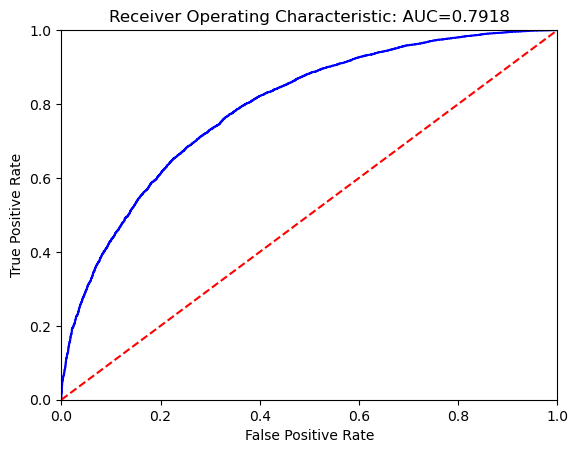

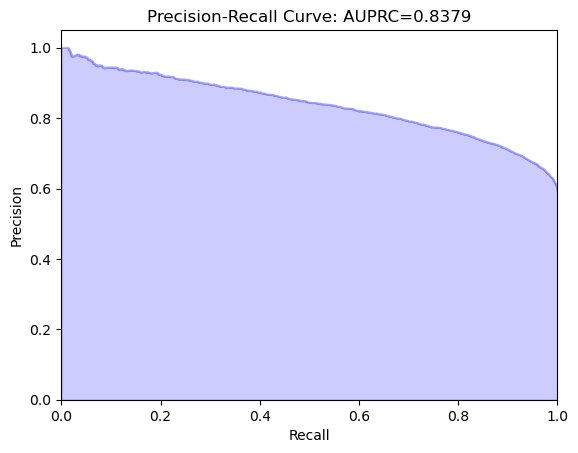

In [20]:
#MY CODE

mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('hospitalization_triage_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)

MLP:
509/509 [==============================] - 0s 429us/step
AUC: 0.7905520499340147
AUPRC: 0.8353260959451934
Sensitivity: 0.7156771319034297
Specificity: 0.7122976856753895
Score thresold: 0.6460053
2.5 97.5


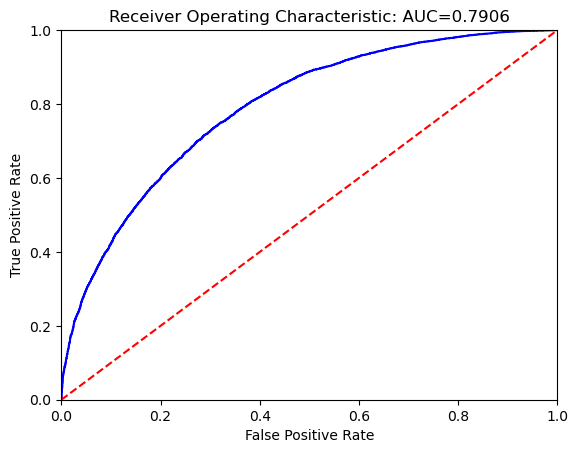

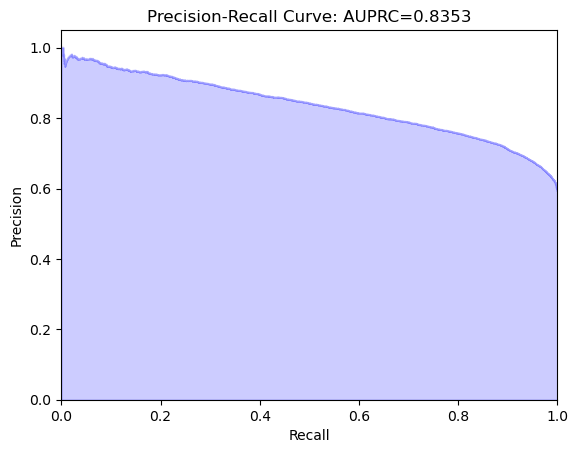

In [21]:
print("MLP:")
probs = mlp.predict(X_val.astype(np.float32))
result = PlotROCCurve(probs, y_val, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)